In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
import pickle
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
warnings.filterwarnings('ignore')

In [47]:
# --- 1. Data Loading and Initial Cleaning ---
print("="*80)
print("SUPPLY CHAIN LATE DELIVERY RISK PREDICTION MODEL")
print("="*80)
print("\n1. Loading and Cleaning Data...")
data = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="ISO-8859-1")
data.columns = data.columns.str.strip()
# Single filter: India as destination country
data = data[data['Order Country'] == 'India']

SUPPLY CHAIN LATE DELIVERY RISK PREDICTION MODEL

1. Loading and Cleaning Data...


In [ ]:
data.apply(lambda x: x.unique())

In [48]:

# Basic data exploration
print(f"   Dataset shape: {data.shape}")
print(f"   Columns: {data.shape[1]}")
missing = data.isnull().sum()
if missing.sum() > 0:
    print(f"\n   Missing values:")
    print(missing[missing > 0])
else:
    print("   No missing values detected")

   Dataset shape: (4783, 53)
   Columns: 53

   Missing values:
Customer Lname            1
Order Zipcode          4783
Product Description    4783
dtype: int64


In [49]:
# --- 3. Target and Feature Selection ---
print("\n3. Selecting Features and Target...")
y = data['Late_delivery_risk'].astype(int)
print(f"\n   Target distribution:")
print(y.value_counts())
print(f"\n   Target proportions:")
print(y.value_counts(normalize=True))

# Feature selection (EXCLUDING potential leakage features)
# Features known AT ORDER TIME only
features = [
    # Temporal features
    'Days for shipment (scheduled)',
    'order_hour',
    'order_day_of_week',
    'order_month',
    'order_quarter',
    'order_day_of_month',
    'is_weekend',
    'is_business_hours',
    'is_month_end',

    # Operational features
    'Shipping Mode',
    'Type',  # Payment Type

    # Product/Department features
    'Department Id',
    'Category Id',
    'Product Category Id',

    # Order characteristics
    'Order Item Quantity',
    'Order Item Discount',
    'Order Item Profit Ratio',
    'Sales',
    'Order Item Total',

    # Engineered features
    'discount_per_item',
    'high_discount_flag',
    'price_per_item',
    'urgent_shipment'
]

# Verify features exist
features = [f for f in features if f in data.columns]
print(f"   Total features selected: {len(features)}")
print(f"   Features: {features}")

X = data[features].copy()

# Handle missing values more carefully
numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(include=['object']).columns

print(f"\n   Numeric features: {len(numeric_features)}")
print(f"   Categorical features: {len(categorical_features)}")

# Fill missing values
for col in numeric_features:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)

for col in categorical_features:
    if X[col].isnull().sum() > 0:
        X[col].fillna('Unknown', inplace=True)


3. Selecting Features and Target...

   Target distribution:
Late_delivery_risk
1    2684
0    2099
Name: count, dtype: int64

   Target proportions:
Late_delivery_risk
1    0.561154
0    0.438846
Name: proportion, dtype: float64
   Total features selected: 11
   Features: ['Days for shipment (scheduled)', 'Shipping Mode', 'Type', 'Department Id', 'Category Id', 'Product Category Id', 'Order Item Quantity', 'Order Item Discount', 'Order Item Profit Ratio', 'Sales', 'Order Item Total']

   Numeric features: 9
   Categorical features: 2



DATA ANALYSIS 1: TARGET VARIABLE DISTRIBUTION


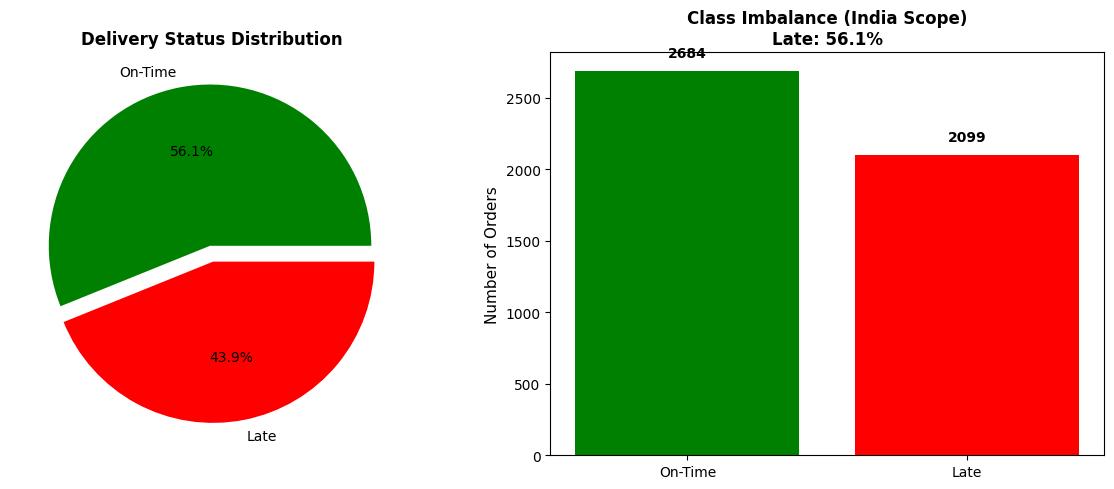

   On-Time deliveries: 2,099 (43.9%)
   Late deliveries:    2,684 (56.1%)
   ✓ Analysis 1 complete - Class imbalance confirmed


In [50]:
# ==========================================
# ADDITIONAL ANALYSIS 1: TARGET DISTRIBUTION
# ==========================================

print("\n" + "="*80)
print("DATA ANALYSIS 1: TARGET VARIABLE DISTRIBUTION")
print("="*80)

# Target distribution
target_counts = y.value_counts()
target_pct = y.value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(target_counts, labels=['On-Time', 'Late'], autopct='%1.1f%%',
            colors=['green', 'red'], explode=(0.05, 0.05))
axes[0].set_title('Delivery Status Distribution', fontsize=12, fontweight='bold')

# Bar chart
axes[1].bar(['On-Time', 'Late'], target_counts, color=['green', 'red'])
axes[1].set_ylabel('Number of Orders', fontsize=11)
axes[1].set_title(f'Class Imbalance (India Scope)\nLate: {target_pct[1]:.1f}%', fontsize=12, fontweight='bold')
for i, v in enumerate(target_counts):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   On-Time deliveries: {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"   Late deliveries:    {target_counts[1]:,} ({target_pct[1]:.1f}%)")
print("   ✓ Analysis 1 complete - Class imbalance confirmed")


DATA ANALYSIS 2: CORRELATION MATRIX


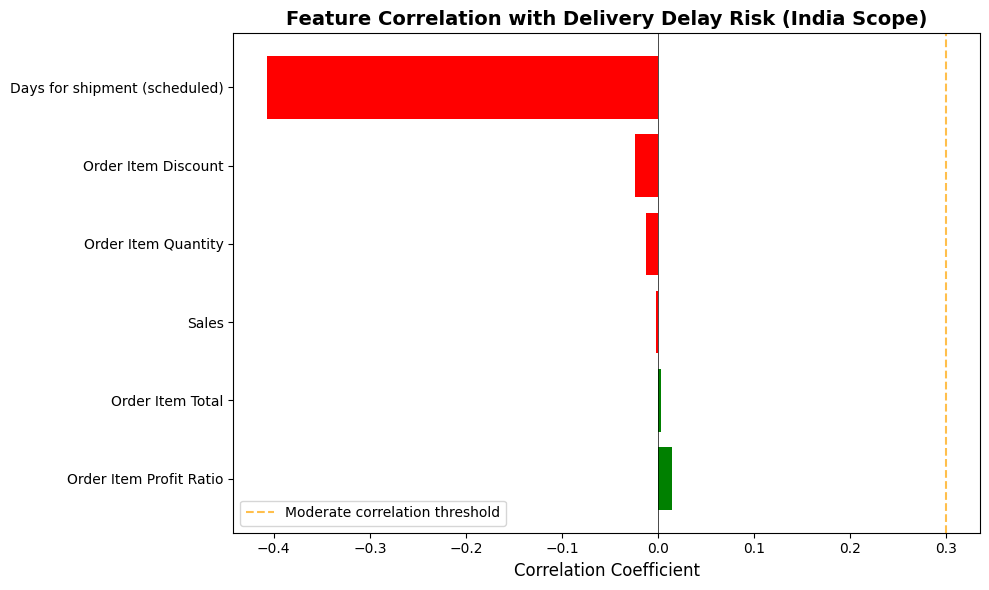


   Top 5 Features Correlated with Late Delivery:
                Feature  Correlation with Late_delivery_risk
Order Item Profit Ratio                             0.014151
       Order Item Total                             0.002772
                  Sales                            -0.001509
    Order Item Quantity                            -0.012750
    Order Item Discount                            -0.024144
   ✓ Analysis 2 complete - Correlation analysis done


In [51]:
# ==========================================
# ADDITIONAL ANALYSIS 2: CORRELATION MATRIX
# ==========================================

print("\n" + "="*80)
print("DATA ANALYSIS 2: CORRELATION MATRIX")
print("="*80)

# Select numerical features for correlation
numerical_for_corr = [
    'Days for shipment (scheduled)',
    'Order Item Quantity',
    'Order Item Discount',
    'Order Item Profit Ratio',
    'Sales',
    'Order Item Total',
    'order_hour',
    'order_day_of_week',
    'order_month',
    'discount_per_item',
    'price_per_item'
]

# Filter existing columns
existing_corr = [col for col in numerical_for_corr if col in X.columns]

# Calculate correlation with target
correlation_with_target = pd.DataFrame({
    'Feature': existing_corr,
    'Correlation with Late_delivery_risk': [X[col].corr(y) for col in existing_corr]
}).sort_values('Correlation with Late_delivery_risk', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in correlation_with_target['Correlation with Late_delivery_risk']]
plt.barh(correlation_with_target['Feature'], correlation_with_target['Correlation with Late_delivery_risk'], color=colors)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Feature Correlation with Delivery Delay Risk (India Scope)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.axvline(x=0.3, color='orange', linestyle='--', alpha=0.7, label='Moderate correlation threshold')
plt.legend()
plt.tight_layout()
plt.savefig('correlation_with_target.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n   Top 5 Features Correlated with Late Delivery:")
print(correlation_with_target.head().to_string(index=False))
print("   ✓ Analysis 2 complete - Correlation analysis done")


DATA ANALYSIS 3: FEATURE DISTRIBUTIONS BY DELIVERY STATUS


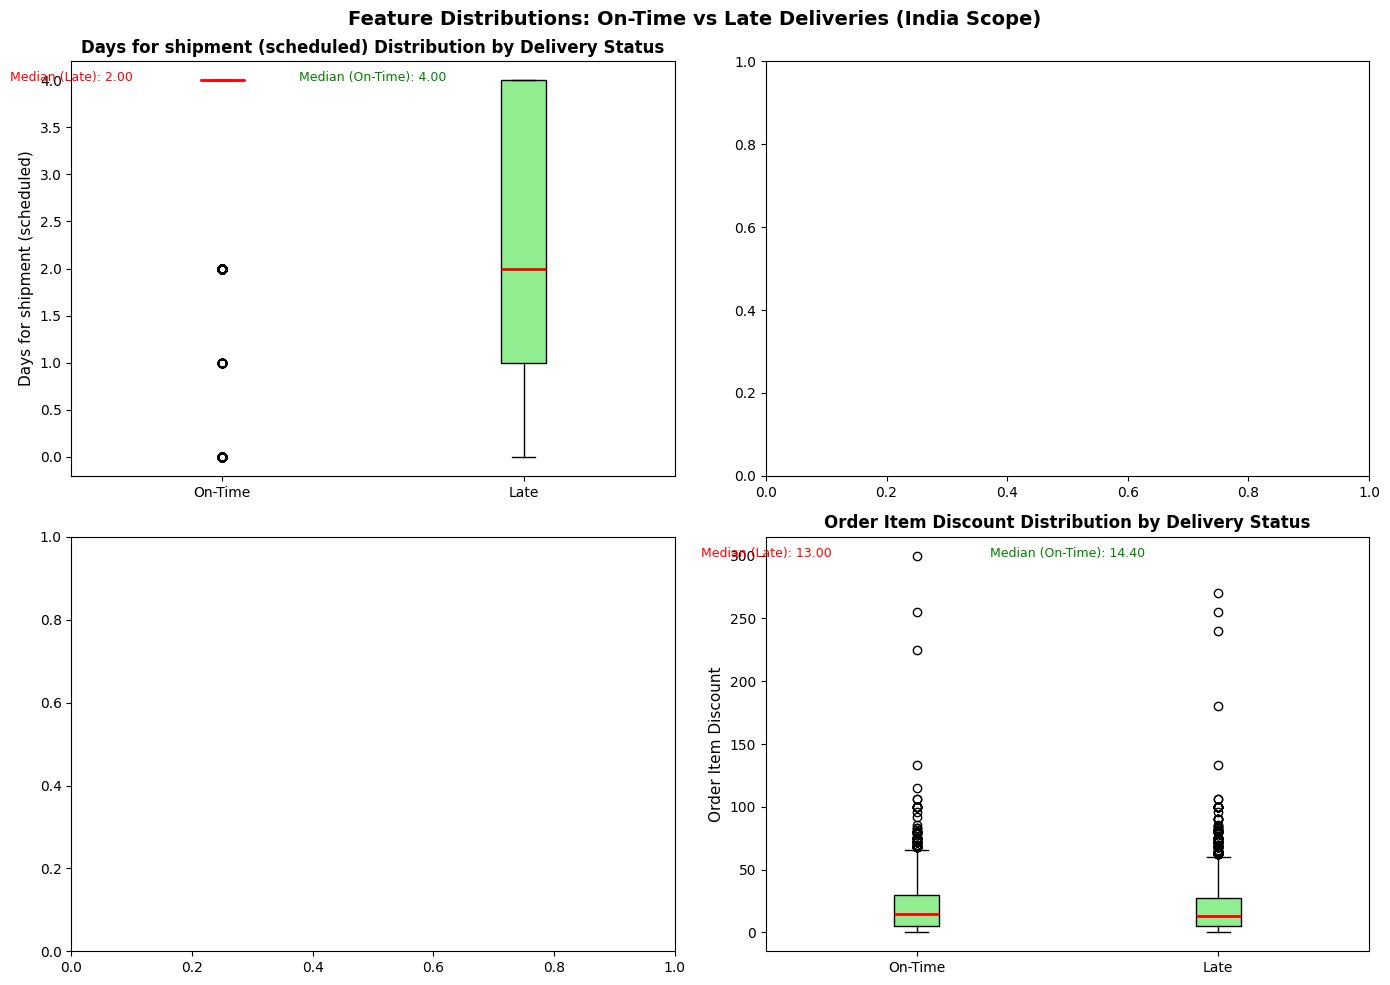

   ✓ Analysis 3 complete - Feature distribution comparison done


In [52]:
# ==========================================
# ADDITIONAL ANALYSIS 3: FEATURE DISTRIBUTIONS
# ==========================================

print("\n" + "="*80)
print("DATA ANALYSIS 3: FEATURE DISTRIBUTIONS BY DELIVERY STATUS")
print("="*80)

# Select top 4 features from SHAP
top_features_shap = ['Days for shipment (scheduled)', 'order_hour', 'order_day_of_week', 'Order Item Discount']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features_shap):
    if feature in X.columns:
        # Create box plot comparing On-Time vs Late
        data_on_time = X[feature][y == 0]
        data_late = X[feature][y == 1]

        axes[idx].boxplot([data_on_time, data_late], labels=['On-Time', 'Late'], patch_artist=True,
                          boxprops=dict(facecolor='lightgreen'), medianprops=dict(color='red', linewidth=2))
        axes[idx].set_ylabel(feature, fontsize=11)
        axes[idx].set_title(f'{feature} Distribution by Delivery Status', fontsize=12, fontweight='bold')

        # Add statistics
        axes[idx].text(0.5, axes[idx].get_ylim()[1]*0.95, f'Median (Late): {data_late.median():.2f}',
                       ha='center', fontsize=9, color='red')
        axes[idx].text(1.5, axes[idx].get_ylim()[1]*0.95, f'Median (On-Time): {data_on_time.median():.2f}',
                       ha='center', fontsize=9, color='green')

plt.suptitle('Feature Distributions: On-Time vs Late Deliveries (India Scope)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("   ✓ Analysis 3 complete - Feature distribution comparison done")


DATA ANALYSIS 4: SHIPPING MODE IMPACT


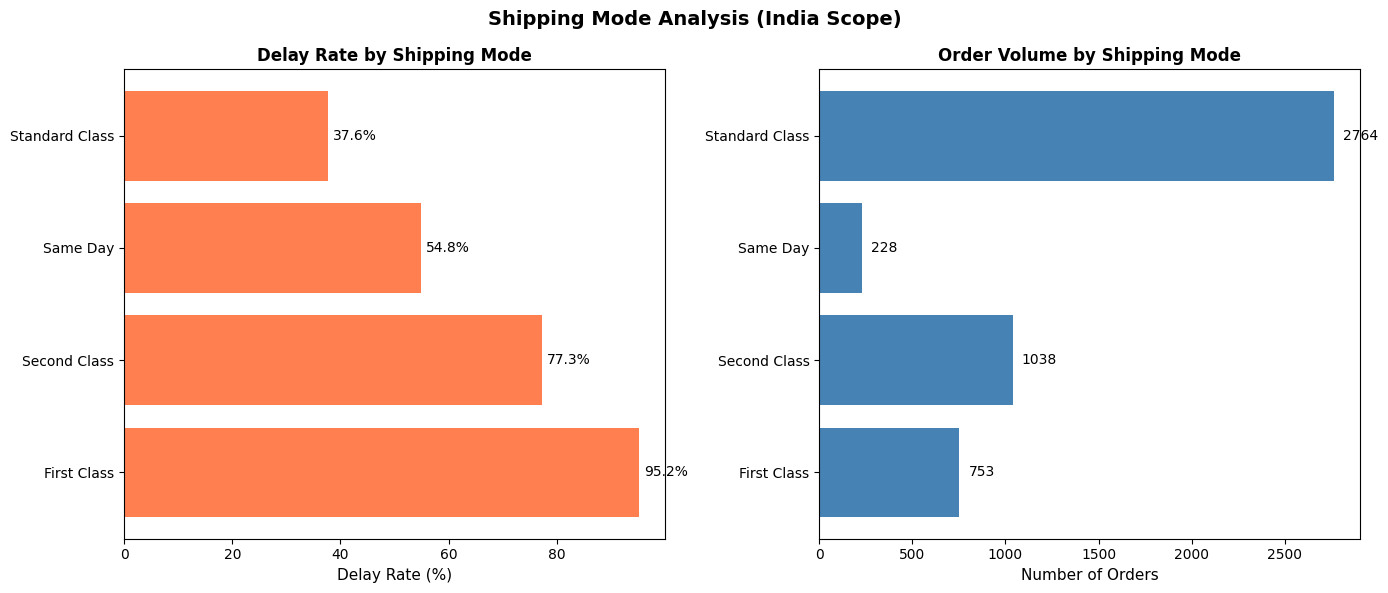


   Shipping Mode Delay Rates:
                Delay Rate %  Order Count
Shipping Mode                            
First Class        95.219124          753
Second Class       77.263969         1038
Same Day           54.824561          228
Standard Class     37.626628         2764
   ✓ Analysis 4 complete - Shipping mode impact quantified


In [53]:
# ==========================================
# ADDITIONAL ANALYSIS 4: SHIPPING MODE ANALYSIS
# ==========================================

print("\n" + "="*80)
print("DATA ANALYSIS 4: SHIPPING MODE IMPACT")
print("="*80)

if 'Shipping Mode' in X.columns:
    # Calculate delay rate by shipping mode
    shipping_analysis = data.groupby('Shipping Mode')['Late_delivery_risk'].agg(['mean', 'count'])
    shipping_analysis.columns = ['Delay Rate', 'Order Count']
    shipping_analysis = shipping_analysis.sort_values('Delay Rate', ascending=False)
    shipping_analysis['Delay Rate %'] = shipping_analysis['Delay Rate'] * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Bar chart - Delay Rate
    axes[0].barh(shipping_analysis.index, shipping_analysis['Delay Rate %'], color='coral')
    axes[0].set_xlabel('Delay Rate (%)', fontsize=11)
    axes[0].set_title('Delay Rate by Shipping Mode', fontsize=12, fontweight='bold')
    for i, v in enumerate(shipping_analysis['Delay Rate %']):
        axes[0].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)

    # Bar chart - Order Count
    axes[1].barh(shipping_analysis.index, shipping_analysis['Order Count'], color='steelblue')
    axes[1].set_xlabel('Number of Orders', fontsize=11)
    axes[1].set_title('Order Volume by Shipping Mode', fontsize=12, fontweight='bold')
    for i, v in enumerate(shipping_analysis['Order Count']):
        axes[1].text(v + 50, i, str(v), va='center', fontsize=10)

    plt.suptitle('Shipping Mode Analysis (India Scope)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shipping_mode_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n   Shipping Mode Delay Rates:")
    print(shipping_analysis[['Delay Rate %', 'Order Count']].to_string())
    print("   ✓ Analysis 4 complete - Shipping mode impact quantified")

In [54]:
# --- 2. Enhanced Feature Engineering ---
print("\n2. Engineering Features...")
data['order_date'] = pd.to_datetime(data['order date (DateOrders)'], errors='coerce')


2. Engineering Features...


In [55]:
# Temporal features
data['order_hour'] = data['order_date'].dt.hour
data['order_day_of_week'] = data['order_date'].dt.dayofweek
data['order_month'] = data['order_date'].dt.month
data['order_quarter'] = data['order_date'].dt.quarter
data['order_day_of_month'] = data['order_date'].dt.day
data['is_weekend'] = (data['order_day_of_week'] >= 5).astype(int)
data['is_business_hours'] = ((data['order_hour'] >= 9) & (data['order_hour'] <= 17)).astype(int)
data['is_month_end'] = (data['order_day_of_month'] >= 25).astype(int)

In [56]:

# Product/Order interaction features
if 'Order Item Quantity' in data.columns and 'Order Item Discount' in data.columns:
    data['discount_per_item'] = data['Order Item Discount'] / (data['Order Item Quantity'] + 1)
    data['high_discount_flag'] = (data['Order Item Discount'] > data['Order Item Discount'].quantile(0.75)).astype(int)

if 'Sales' in data.columns and 'Order Item Quantity' in data.columns:
    data['price_per_item'] = data['Sales'] / (data['Order Item Quantity'] + 1)

# Shipping complexity score
if 'Days for shipment (scheduled)' in data.columns:
    data['urgent_shipment'] = (data['Days for shipment (scheduled)'] <= 2).astype(int)

# Drop invalid rows
initial_rows = len(data)
data = data.dropna(subset=['order_date', 'Late_delivery_risk'])
print(f"   Rows removed due to missing critical data: {initial_rows - len(data)}")
print(f"   Rows after cleaning: {len(data)}")

   Rows removed due to missing critical data: 0
   Rows after cleaning: 4783



DATA ANALYSIS 5: TEMPORAL PATTERNS


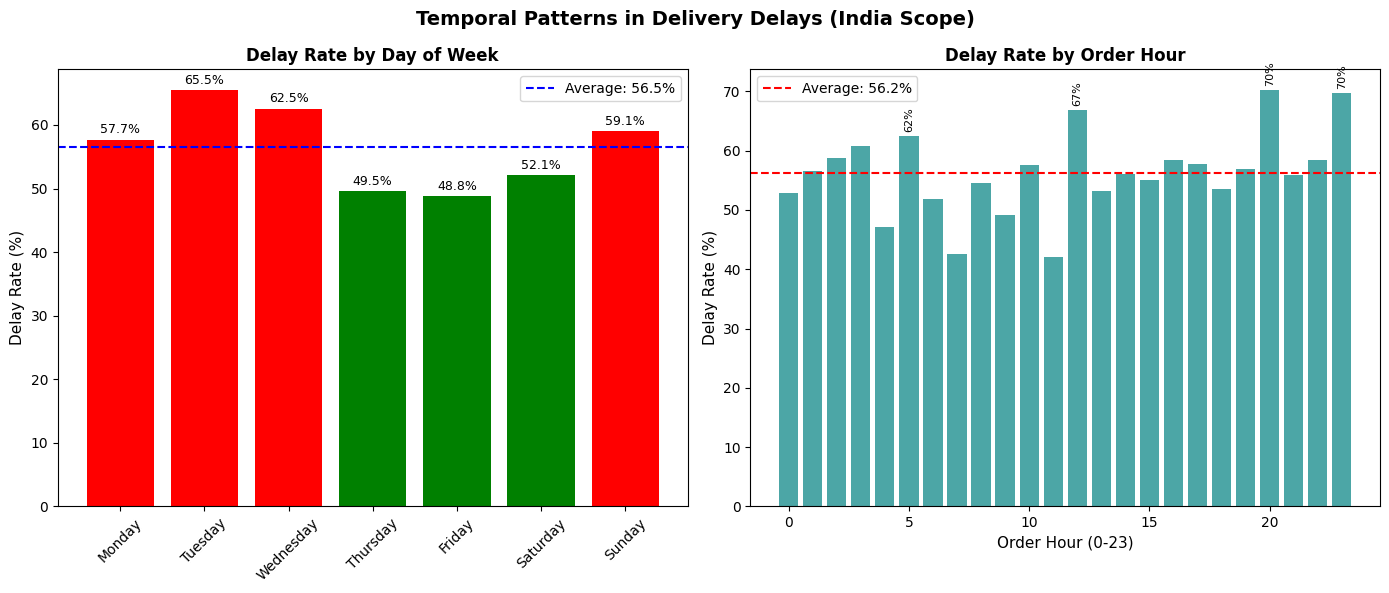


   Day with highest delay: Tuesday (65.5%)
   Day with lowest delay: Friday (48.8%)
   Hour with highest delay: 20:00 (70.2%)
   Hour with lowest delay: 11:00 (42.1%)
   ✓ Analysis 5 complete - Temporal patterns identified


In [57]:
# ==========================================
# ADDITIONAL ANALYSIS 5: TEMPORAL PATTERNS
# ==========================================

print("\n" + "="*80)
print("DATA ANALYSIS 5: TEMPORAL PATTERNS")
print("="*80)

# Create temporary date columns if not already present
if 'order_date' not in data.columns:
    data['order_date'] = pd.to_datetime(data['order date (DateOrders)'], errors='coerce')

data['order_day_temp'] = data['order_date'].dt.dayofweek
data['order_hour_temp'] = data['order_date'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Day of week analysis
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_delay = []

for day in range(7):
    mask = data['order_day_temp'] == day
    if mask.sum() > 0:
        delay_rate = data[mask]['Late_delivery_risk'].mean() * 100
        day_delay.append(delay_rate)
    else:
        day_delay.append(0)

# Calculate the mean for the line (FIXED: removed undefined variable)
day_delay_mean = np.mean(day_delay)
colors_day = ['red' if x > day_delay_mean else 'green' for x in day_delay]

axes[0].bar(day_names, day_delay, color=colors_day)
axes[0].set_ylabel('Delay Rate (%)', fontsize=11)
axes[0].set_title('Delay Rate by Day of Week', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=day_delay_mean, color='blue', linestyle='--', label=f'Average: {day_delay_mean:.1f}%')
axes[0].legend()

# Add value labels on bars
for i, v in enumerate(day_delay):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# Hour of day analysis
hour_delay = []
for hour in range(24):
    mask = data['order_hour_temp'] == hour
    if mask.sum() > 0:
        delay_rate = data[mask]['Late_delivery_risk'].mean() * 100
        hour_delay.append(delay_rate)
    else:
        hour_delay.append(0)

hour_delay_mean = np.mean(hour_delay)

axes[1].bar(range(24), hour_delay, color='teal', alpha=0.7)
axes[1].set_xlabel('Order Hour (0-23)', fontsize=11)
axes[1].set_ylabel('Delay Rate (%)', fontsize=11)
axes[1].set_title('Delay Rate by Order Hour', fontsize=12, fontweight='bold')
axes[1].axhline(y=hour_delay_mean, color='red', linestyle='--', label=f'Average: {hour_delay_mean:.1f}%')
axes[1].legend()

# Add value labels on peak hours
for i, v in enumerate(hour_delay):
    if v > hour_delay_mean + 5:  # Label only significantly higher hours
        axes[1].text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=8, rotation=90)

plt.suptitle('Temporal Patterns in Delivery Delays (India Scope)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n   Day with highest delay: {day_names[np.argmax(day_delay)]} ({max(day_delay):.1f}%)")
print(f"   Day with lowest delay: {day_names[np.argmin(day_delay)]} ({min(day_delay):.1f}%)")
print(f"   Hour with highest delay: {np.argmax(hour_delay)}:00 ({max(hour_delay):.1f}%)")
print(f"   Hour with lowest delay: {np.argmin(hour_delay)}:00 ({min(hour_delay):.1f}%)")
print("   ✓ Analysis 5 complete - Temporal patterns identified")

# Clean up temporary columns
data = data.drop(['order_day_temp', 'order_hour_temp'], axis=1, errors='ignore')

In [58]:
# --- 4. Train-Test Split ---
print("\n4. Splitting Data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"   Train set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test set:  {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n   Train target distribution:")
print(y_train.value_counts(normalize=True))


4. Splitting Data...
   Train set: 3826 samples (80.0%)
   Test set:  957 samples (20.0%)

   Train target distribution:
Late_delivery_risk
1    0.56116
0    0.43884
Name: proportion, dtype: float64


In [59]:
# --- 5. Preprocessing Setup ---
print("\n5. Setting up Preprocessing Pipeline...")
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=50), categorical_cols)
], remainder='passthrough')


5. Setting up Preprocessing Pipeline...


In [60]:
# --- 6. Model Training ---
print("\n6. Training Models...")

# Calculate class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"   Class imbalance ratio: {scale_pos_weight:.2f}")

# XGBoost with optimized parameters
pipe_xgb = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        colsample_bytree=0.7,
        subsample=0.7,
        min_child_weight=5,
        gamma=0.2,
        reg_alpha=0.5,  # L1 regularization
        reg_lambda=2.0   # L2 regularization
    ))
])

# RandomForest with balanced weights
pipe_rf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])


6. Training Models...
   Class imbalance ratio: 0.78


In [61]:

# Train models
print("   Training XGBoost...")
pipe_xgb.fit(X_train, y_train)
print("   ✓ XGBoost trained")

print("   Training RandomForest...")
pipe_rf.fit(X_train, y_train)
print("   ✓ RandomForest trained")

   Training XGBoost...
   ✓ XGBoost trained
   Training RandomForest...
   ✓ RandomForest trained


In [62]:
# --- 7. Cross-Validation ---
print("\n7. Cross-Validation (5-Fold)...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("   XGBoost CV Scores:")
cv_scores_xgb = cross_val_score(pipe_xgb, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"      Mean AUC: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")

print("   RandomForest CV Scores:")
cv_scores_rf = cross_val_score(pipe_rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"      Mean AUC: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")



7. Cross-Validation (5-Fold)...
   XGBoost CV Scores:
      Mean AUC: 0.7636 (+/- 0.0110)
   RandomForest CV Scores:
      Mean AUC: 0.7574 (+/- 0.0101)


In [63]:
# --- 8. Enhanced Evaluation ---
print("\n" + "="*80)
print("8. MODEL EVALUATION")
print("="*80)

def evaluate(name, model, X_train, y_train, X_test, y_test):
    # Train predictions
    train_preds = model.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)

    # Test predictions
    test_preds = model.predict(X_test)
    test_probs = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, test_preds)
    prec = precision_score(y_test, test_preds, zero_division=0)
    rec = recall_score(y_test, test_preds, zero_division=0)
    f1 = f1_score(y_test, test_preds, zero_division=0)
    auc = roc_auc_score(y_test, test_probs)

    # Confusion matrix
    cm = confusion_matrix(y_test, test_preds)

    print(f"\n{'='*80}")
    print(f"  {name}")
    print(f"{'='*80}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {acc:.4f}")
    print(f"  Precision:      {prec:.4f} (of predicted late, % actually late)")
    print(f"  Recall:         {rec:.4f} (of actual late, % predicted late)")
    print(f"  F1 Score:       {f1:.4f}")
    print(f"  ROC-AUC:        {auc:.4f}")

    print(f"\n  Confusion Matrix:")
    print(f"                Predicted")
    print(f"                On-Time  Late")
    print(f"  Actual On-Time  {cm[0][0]:6d}  {cm[0][1]:5d}")
    print(f"  Actual Late     {cm[1][0]:6d}  {cm[1][1]:5d}")

    print(f"\n  Classification Report:")
    print(classification_report(y_test, test_preds, target_names=['On-Time', 'Late']))

    # Calculate business metrics
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"  Specificity (True Negative Rate): {specificity:.4f}")

    return auc, test_probs, test_preds

auc_xgb, probs_xgb, preds_xgb = evaluate("XGBoost", pipe_xgb, X_train, y_train, X_test, y_test)
auc_rf, probs_rf, preds_rf = evaluate("RandomForest", pipe_rf, X_train, y_train, X_test, y_test)


8. MODEL EVALUATION

  XGBoost
  Train Accuracy: 0.7185
  Test Accuracy:  0.6959
  Precision:      0.8289 (of predicted late, % actually late)
  Recall:         0.5773 (of actual late, % predicted late)
  F1 Score:       0.6806
  ROC-AUC:        0.7350

  Confusion Matrix:
                Predicted
                On-Time  Late
  Actual On-Time     356     64
  Actual Late        227    310

  Classification Report:
              precision    recall  f1-score   support

     On-Time       0.61      0.85      0.71       420
        Late       0.83      0.58      0.68       537

    accuracy                           0.70       957
   macro avg       0.72      0.71      0.70       957
weighted avg       0.73      0.70      0.69       957

  Specificity (True Negative Rate): 0.8476

  RandomForest
  Train Accuracy: 0.7804
  Test Accuracy:  0.6865
  Precision:      0.7912 (of predicted late, % actually late)
  Recall:         0.5996 (of actual late, % predicted late)
  F1 Score:       0.6


SHAP ANALYSIS - Explaining Model Predictions
   Interpreting XGBoost model with SHAP...
   Using 500 samples for SHAP analysis


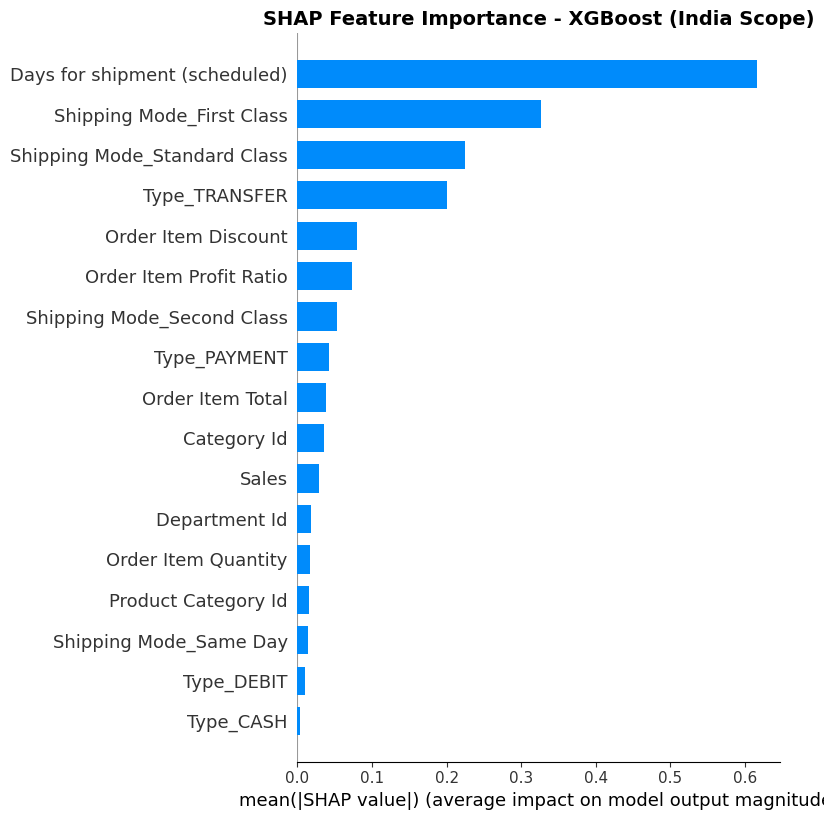

   ✓ Saved: shap_bar_importance.png


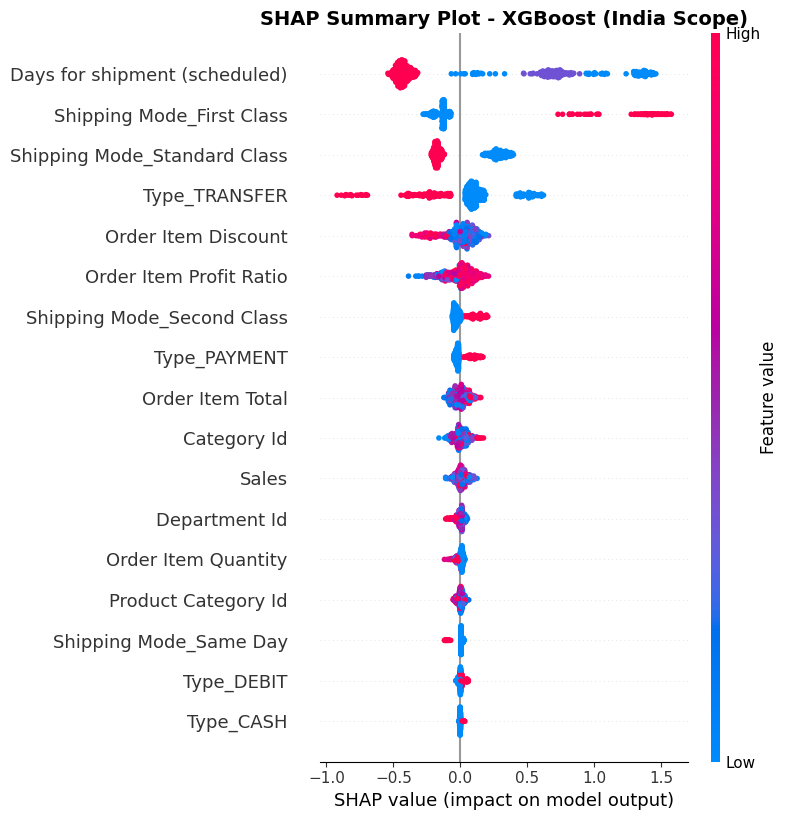

   ✓ Saved: shap_summary_plot.png


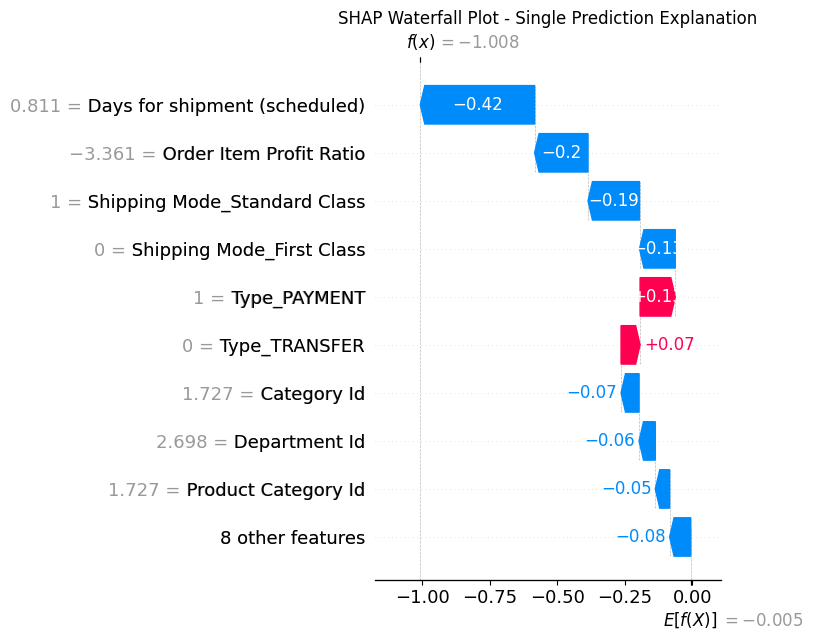

   ✓ Saved: shap_waterfall_sample.png

   Top 10 Features by SHAP Importance (India Scope):
   --------------------------------------------------
   Days for shipment (scheduled)            : 0.6160
   Shipping Mode_First Class                : 0.3262
   Shipping Mode_Standard Class             : 0.2241
   Type_TRANSFER                            : 0.2000
   Order Item Discount                      : 0.0803
   Order Item Profit Ratio                  : 0.0734
   Shipping Mode_Second Class               : 0.0531
   Type_PAYMENT                             : 0.0428
   Order Item Total                         : 0.0381
   Category Id                              : 0.0358

 Saved: shap_feature_importance.csv



In [64]:
#==========================================
# SHAP ANALYSIS (Model Interpretability)
# ==========================================

print("\n" + "="*80)
print("SHAP ANALYSIS - Explaining Model Predictions")
print("="*80)

try:
    import shap
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    # Get the best model (XGBoost since it had higher AUC)
    best_model = pipe_xgb
    best_model_name = "XGBoost"

    print(f"   Interpreting {best_model_name} model with SHAP...")

    # Get preprocessed training data for SHAP explanation
    # This transforms the data the same way your model does
    X_train_preprocessed = best_model.named_steps['pre'].transform(X_train)

    # Get feature names after preprocessing
    cat_features = best_model.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
    feature_names_all = numeric_cols + list(cat_features)

    # Create DataFrame for SHAP
    X_train_df = pd.DataFrame(X_train_preprocessed, columns=feature_names_all)

    # Use a subset of data for faster SHAP calculation (500 samples is sufficient)
    sample_size = min(500, len(X_train_df))
    X_sample = X_train_df.sample(n=sample_size, random_state=42)
    print(f"   Using {sample_size} samples for SHAP analysis")

    # Create SHAP explainer for tree-based model
    best_model_raw = best_model.named_steps['clf']
    explainer = shap.TreeExplainer(best_model_raw)

    # Calculate SHAP values
    shap_values = explainer.shap_values(X_sample)

    # --- Plot 1: Bar Chart (Feature Importance Ranking) ---
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance - {best_model_name} (India Scope)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_bar_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    # plt.close()
    print("   ✓ Saved: shap_bar_importance.png")

    # --- Plot 2: Summary Plot (Shows impact direction) ---
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title(f'SHAP Summary Plot - {best_model_name} (India Scope)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    # plt.close()
    print("   ✓ Saved: shap_summary_plot.png")

    # --- Plot 3: Waterfall Plot for first test sample (optional) ---
    # This shows how features contributed to a single prediction
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap.Explanation(values=shap_values[0],
                                          base_values=explainer.expected_value,
                                          data=X_sample.iloc[0],
                                          feature_names=feature_names_all), show=False)
    plt.title(f'SHAP Waterfall Plot - Single Prediction Explanation', fontsize=12)
    plt.tight_layout()
    plt.savefig('shap_waterfall_sample.png', dpi=300, bbox_inches='tight')
    plt.show()
    # plt.close()
    print("   ✓ Saved: shap_waterfall_sample.png")

    # --- Get Top 10 Features by Mean SHAP Value ---
    shap_importance = pd.DataFrame({
        'feature': feature_names_all,
        'mean_shap_value': np.abs(shap_values).mean(axis=0)
    }).sort_values('mean_shap_value', ascending=False)

    print("\n   Top 10 Features by SHAP Importance (India Scope):")
    print("   " + "-" * 50)
    for i, row in shap_importance.head(10).iterrows():
        print(f"   {row['feature'][:40]:<40} : {row['mean_shap_value']:.4f}")

    # Save SHAP importance to CSV
    shap_importance.to_csv('shap_feature_importance.csv', index=False)
    print("\n Saved: shap_feature_importance.csv")

except ImportError:
    print("Note: SHAP library not installed. Install with: pip install shap")
except Exception as e:
    print(f"Note: SHAP analysis could not complete: {e}")
    print("Model evaluation continues without SHAP.")

print("\n" + "="*80)


9. FEATURE IMPORTANCE

XGBoost - Top 20 Features:
                      Feature  Importance
 Shipping Mode_Standard Class    0.484825
Days for shipment (scheduled)    0.187055
    Shipping Mode_First Class    0.078855
   Shipping Mode_Second Class    0.046378
       Shipping Mode_Same Day    0.044512
                Type_TRANSFER    0.027517
                    Type_CASH    0.014497
                 Type_PAYMENT    0.014216
          Order Item Discount    0.012939
                        Sales    0.012773
          Product Category Id    0.012312
      Order Item Profit Ratio    0.012002
             Order Item Total    0.011331
                Department Id    0.010928
          Order Item Quantity    0.010828
                  Category Id    0.010710
                   Type_DEBIT    0.008322
   ✓ Feature importance plot saved: xgboost_feature_importance.png


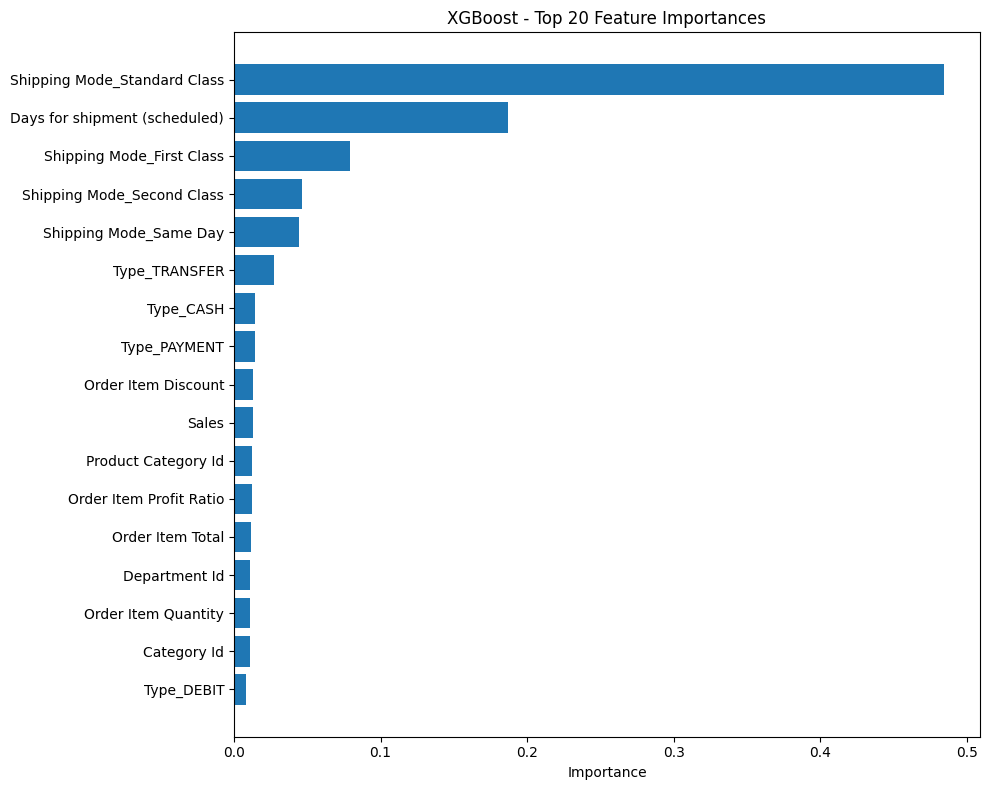


RandomForest - Top 20 Features:
                      Feature  Importance
Days for shipment (scheduled)    0.174770
 Shipping Mode_Standard Class    0.151001
      Order Item Profit Ratio    0.105512
          Order Item Discount    0.099969
    Shipping Mode_First Class    0.098341
             Order Item Total    0.094940
                        Sales    0.048186
   Shipping Mode_Second Class    0.044446
          Product Category Id    0.037329
                  Category Id    0.036309
                Type_TRANSFER    0.026973
          Order Item Quantity    0.020161
                Department Id    0.019508
       Shipping Mode_Same Day    0.013315
                   Type_DEBIT    0.012056
                 Type_PAYMENT    0.010931
                    Type_CASH    0.006253
   ✓ Feature importance plot saved: randomforest_feature_importance.png


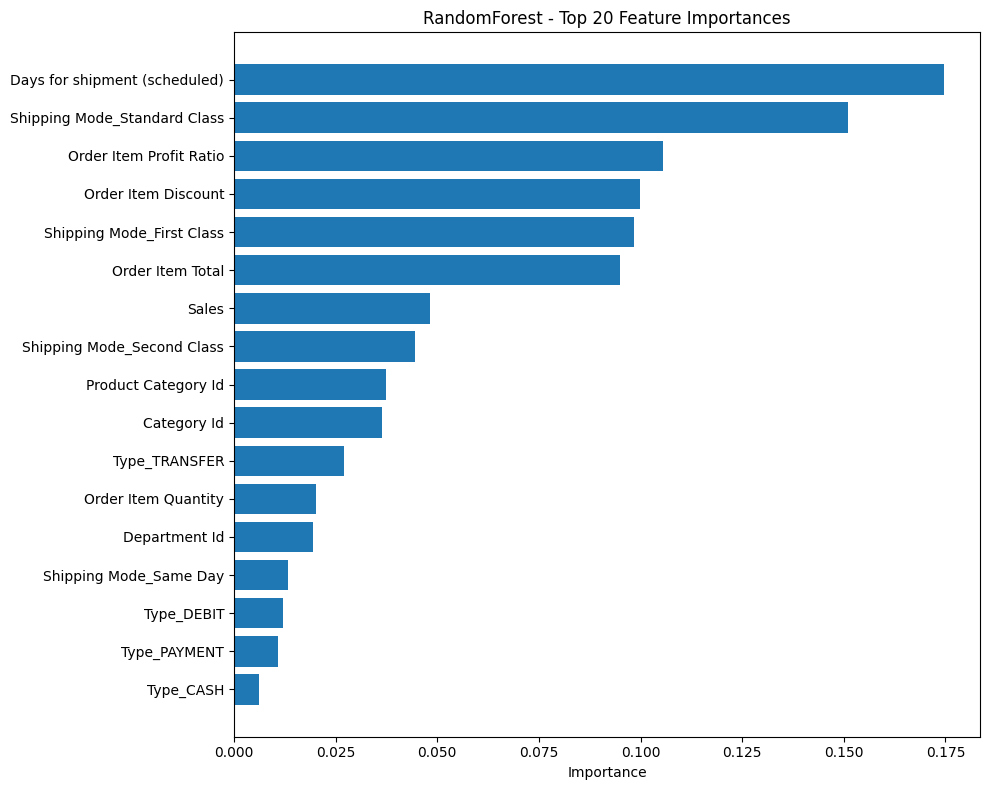

In [65]:
# --- 9. Feature Importance ---
print("\n" + "="*80)
print("9. FEATURE IMPORTANCE")
print("="*80)

def plot_feature_importance(model, name, top_n=20):
    if hasattr(model.named_steps['clf'], 'feature_importances_'):
        # Get feature names
        cat_features = model.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
        feature_names = numeric_cols + list(cat_features)

        # Get importances
        importances = model.named_steps['clf'].feature_importances_

        # Create DataFrame
        importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        print(f"\n{name} - Top {top_n} Features:")
        print(importance_df.head(top_n).to_string(index=False))

        # Plot
        plt.figure(figsize=(10, 8))
        top_features = importance_df.head(top_n)
        plt.barh(range(len(top_features)), top_features['Importance'])
        plt.yticks(range(len(top_features)), top_features['Feature'])
        plt.xlabel('Importance')
        plt.title(f'{name} - Top {top_n} Feature Importances')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'{name.lower()}_feature_importance.png', dpi=300, bbox_inches='tight')
        print(f"   ✓ Feature importance plot saved: {name.lower()}_feature_importance.png")
        plt.show()
        # plt.close()

        return importance_df

# os.makedirs("models_fixed", exist_ok=True)
importance_xgb = plot_feature_importance(pipe_xgb, "XGBoost", top_n=20)
importance_rf = plot_feature_importance(pipe_rf, "RandomForest", top_n=20)


10. Generating ROC Curves...
   ✓ ROC curve saved: roc_curves.png


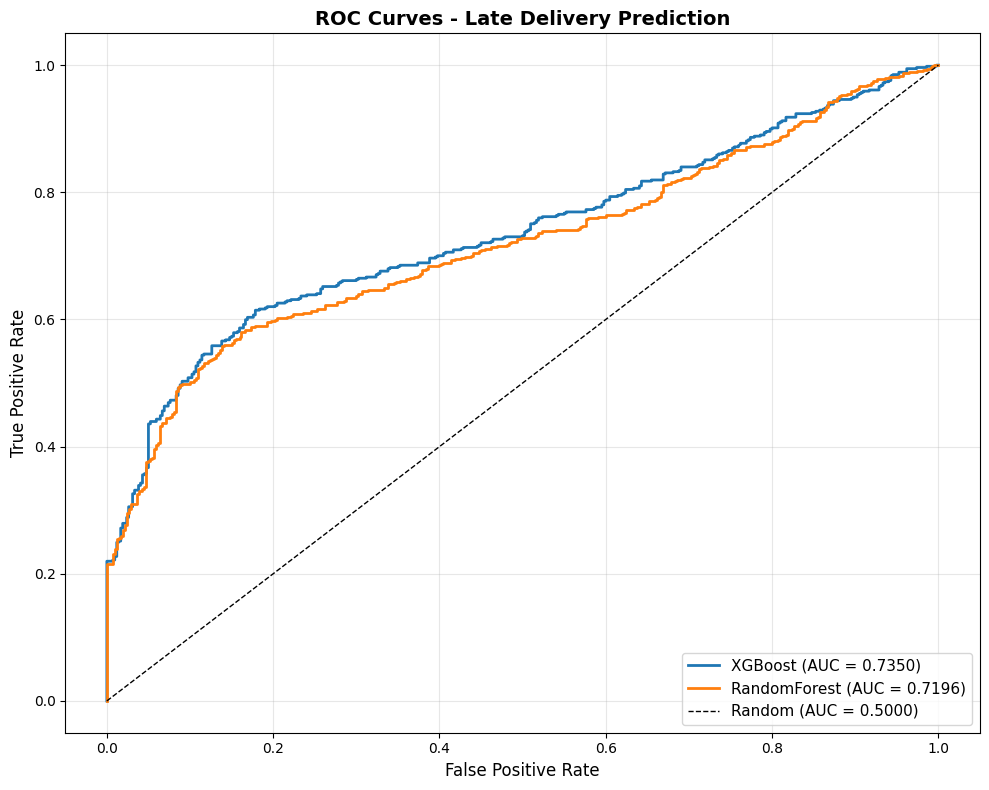

In [66]:


# --- 10. ROC Curve Visualization ---
print("\n10. Generating ROC Curves...")
plt.figure(figsize=(10, 8))

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, probs_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2)

# RandomForest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC = {auc_rf:.4f})', linewidth=2)

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5000)', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Late Delivery Prediction', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
print("   ✓ ROC curve saved: roc_curves.png")
plt.show()
# plt.close()


GENERATING PRECISION-RECALL CURVE


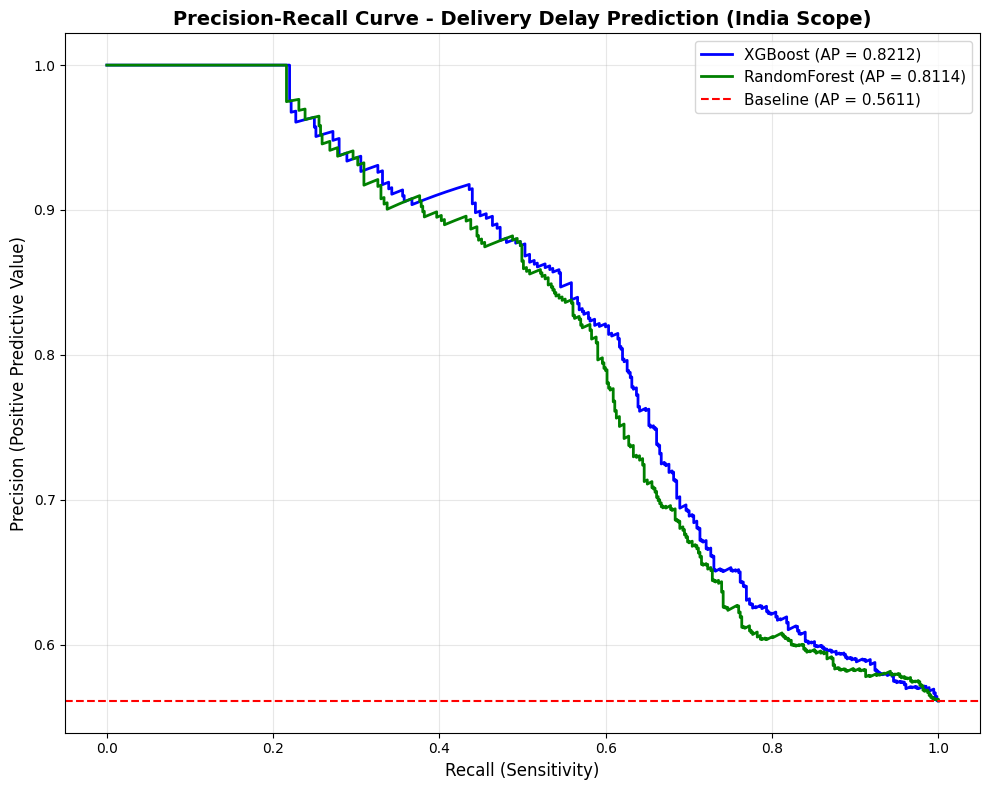

   XGBoost Average Precision: 0.8212
   RandomForest Average Precision: 0.8114
   ✓ Saved: precision_recall_curve.png


In [67]:
# ==========================================
# PRECISION-RECALL CURVE
# ==========================================

print("\n" + "="*80)
print("GENERATING PRECISION-RECALL CURVE")
print("="*80)

from sklearn.metrics import precision_recall_curve, average_precision_score

# Get predicted probabilities
y_probs_xgb = pipe_xgb.predict_proba(X_test)[:, 1]
y_probs_rf = pipe_rf.predict_proba(X_test)[:, 1]

# Calculate precision-recall curves
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_probs_xgb)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_probs_rf)

# Calculate average precision (AP)
ap_xgb = average_precision_score(y_test, y_probs_xgb)
ap_rf = average_precision_score(y_test, y_probs_rf)

# Plot
plt.figure(figsize=(10, 8))

plt.plot(recall_xgb, precision_xgb, linewidth=2,
         label=f'XGBoost (AP = {ap_xgb:.4f})', color='blue')
plt.plot(recall_rf, precision_rf, linewidth=2,
         label=f'RandomForest (AP = {ap_rf:.4f})', color='green')

# Baseline (no-skill classifier)
baseline = y_test.sum() / len(y_test)
plt.axhline(y=baseline, color='red', linestyle='--',
            label=f'Baseline (AP = {baseline:.4f})')

plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curve - Delivery Delay Prediction (India Scope)',
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()
# plt.close()

print(f"   XGBoost Average Precision: {ap_xgb:.4f}")
print(f"   RandomForest Average Precision: {ap_rf:.4f}")
print("   ✓ Saved: precision_recall_curve.png")


GENERATING SHAP WATERFALL PLOT


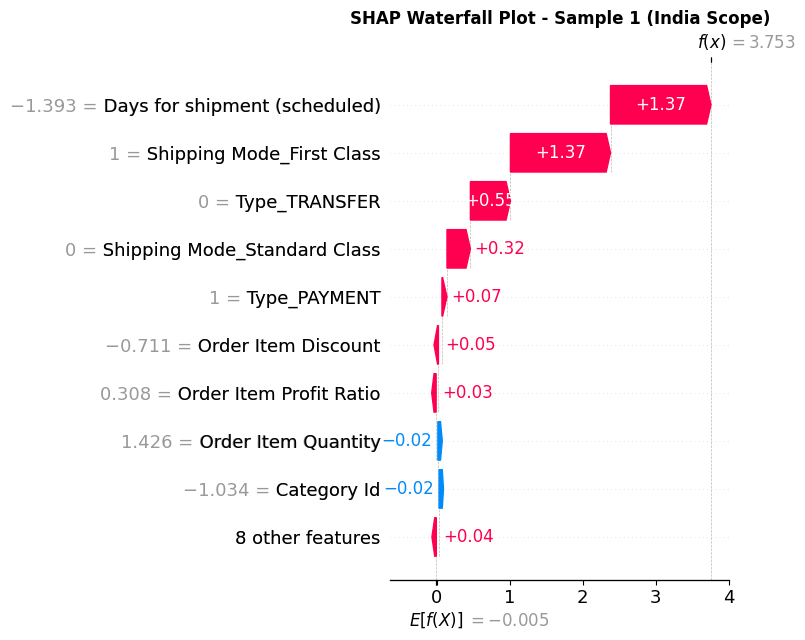

   ✓ Saved: shap_waterfall_sample_1.png


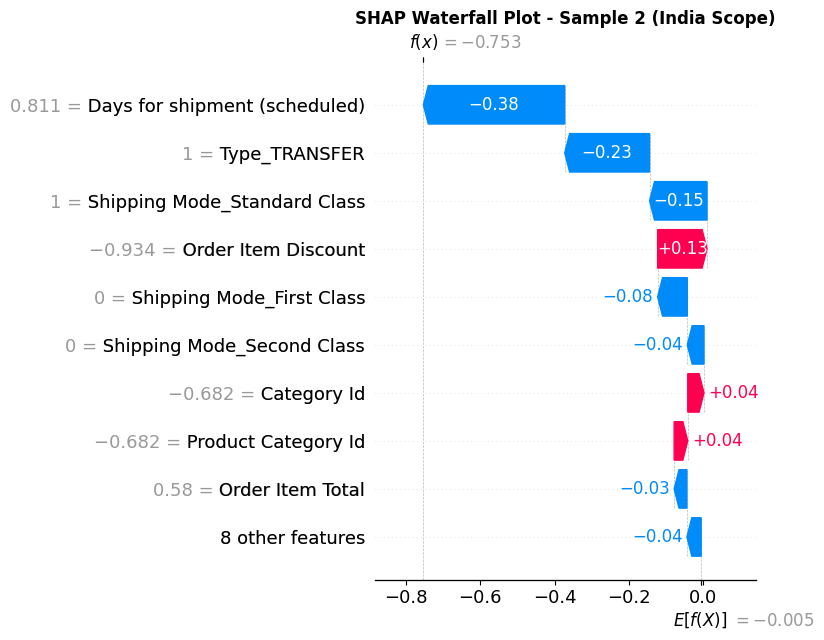

   ✓ Saved: shap_waterfall_sample_2.png

   Waterfall Plot Interpretation:
   - Red bars: Features pushing prediction toward 'Late'
   - Blue bars: Features pushing prediction toward 'On-Time'
   - Base value: Starting prediction before considering features


In [68]:
# ==========================================
# SHAP WATERFALL PLOT - Single Prediction Explanation
# ==========================================

print("\n" + "="*80)
print("GENERATING SHAP WATERFALL PLOT")
print("="*80)

try:
    import shap

    # Get preprocessed data for SHAP
    X_train_preprocessed = pipe_xgb.named_steps['pre'].transform(X_train)
    cat_features = pipe_xgb.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
    feature_names_all = numeric_cols + list(cat_features)
    X_train_df = pd.DataFrame(X_train_preprocessed, columns=feature_names_all)

    # Get a sample of test data
    X_test_preprocessed = pipe_xgb.named_steps['pre'].transform(X_test)
    X_test_df = pd.DataFrame(X_test_preprocessed, columns=feature_names_all)

    # Create explainer
    explainer = shap.TreeExplainer(pipe_xgb.named_steps['clf'])

    # Get SHAP values for first 5 test samples
    shap_values_sample = explainer.shap_values(X_test_df.iloc[:5])
    expected_value = explainer.expected_value

    # Create waterfall plots for first 2 samples
    for i in range(2):
        plt.figure(figsize=(12, 7))
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values_sample[i],
                base_values=expected_value,
                data=X_test_df.iloc[i],
                feature_names=feature_names_all
            ),
            show=False,
            max_display=10
        )
        plt.title(f'SHAP Waterfall Plot - Sample {i+1} (India Scope)',
                  fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'shap_waterfall_sample_{i+1}.png', dpi=300, bbox_inches='tight')
        plt.show()
        # plt.close()
        print(f"   ✓ Saved: shap_waterfall_sample_{i+1}.png")

    print("\n   Waterfall Plot Interpretation:")
    print("   - Red bars: Features pushing prediction toward 'Late'")
    print("   - Blue bars: Features pushing prediction toward 'On-Time'")
    print("   - Base value: Starting prediction before considering features")

except Exception as e:
    print(f"   Note: Could not generate waterfall plots: {e}")


GENERATING LEARNING CURVES (For overfitting diagnosis)


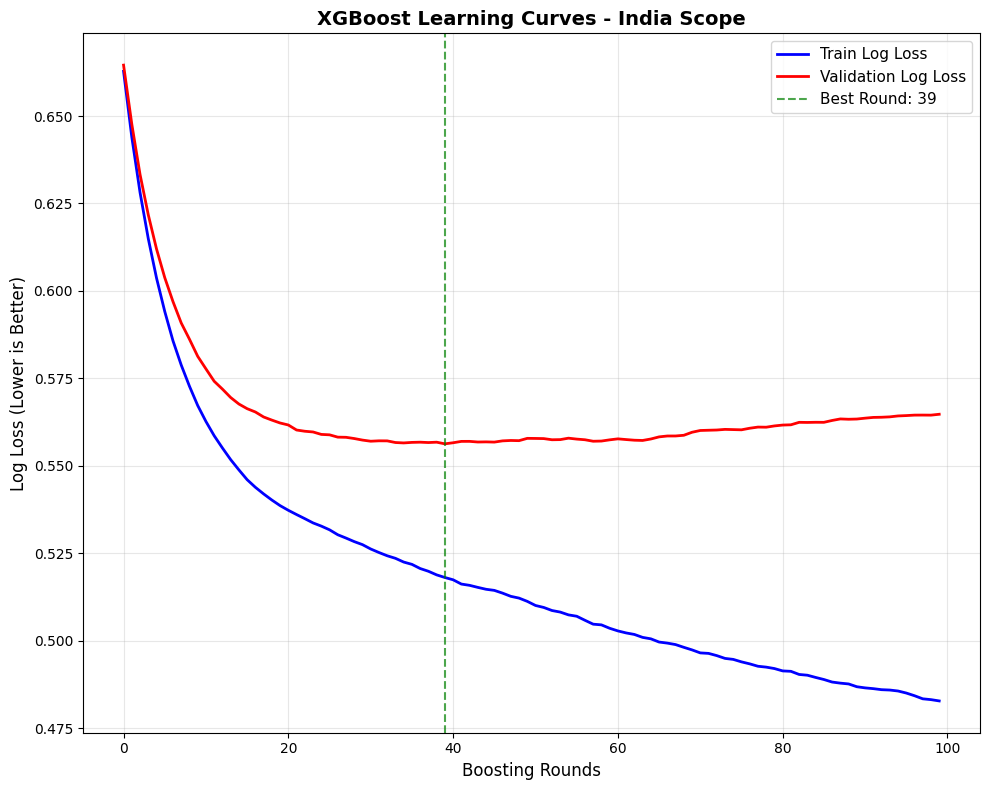

   Best validation log loss: 0.5563 at round 39
   ✓ Learning curves saved

   Interpretation:
   - If both curves decrease together → No overfitting ✓
   - If validation goes up while train goes down → Overfitting ✗


In [69]:
# ==========================================
# LEARNING CURVES ONLY
# ==========================================

print("\n" + "="*80)
print("GENERATING LEARNING CURVES (For overfitting diagnosis)")
print("="*80)

from xgboost import XGBClassifier

# Preprocess data (use your existing preprocessor)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Create a temporary model just for learning curves
temp_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,  # Shallow trees to see progress
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

# Train with evaluation set
eval_set = [(X_train_processed, y_train), (X_test_processed, y_test)]
temp_model.fit(X_train_processed, y_train, eval_set=eval_set, verbose=False)

# Get training history
results = temp_model.evals_result()

# Plot learning curves
plt.figure(figsize=(10, 8))

epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.plot(x_axis, results['validation_0']['logloss'],
         label='Train Log Loss', linewidth=2, color='blue')
plt.plot(x_axis, results['validation_1']['logloss'],
         label='Validation Log Loss', linewidth=2, color='red')

plt.xlabel('Boosting Rounds', fontsize=12)
plt.ylabel('Log Loss (Lower is Better)', fontsize=12)
plt.title('XGBoost Learning Curves - India Scope', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Find best round
best_round = np.argmin(results['validation_1']['logloss'])
plt.axvline(x=best_round, color='green', linestyle='--', alpha=0.7, label=f'Best Round: {best_round}')

plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('xgboost_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"   Best validation log loss: {min(results['validation_1']['logloss']):.4f} at round {best_round}")
print("   ✓ Learning curves saved")
print("\n   Interpretation:")
print("   - If both curves decrease together → No overfitting ✓")
print("   - If validation goes up while train goes down → Overfitting ✗")


GENERATING CONFUSION MATRIX HEATMAP


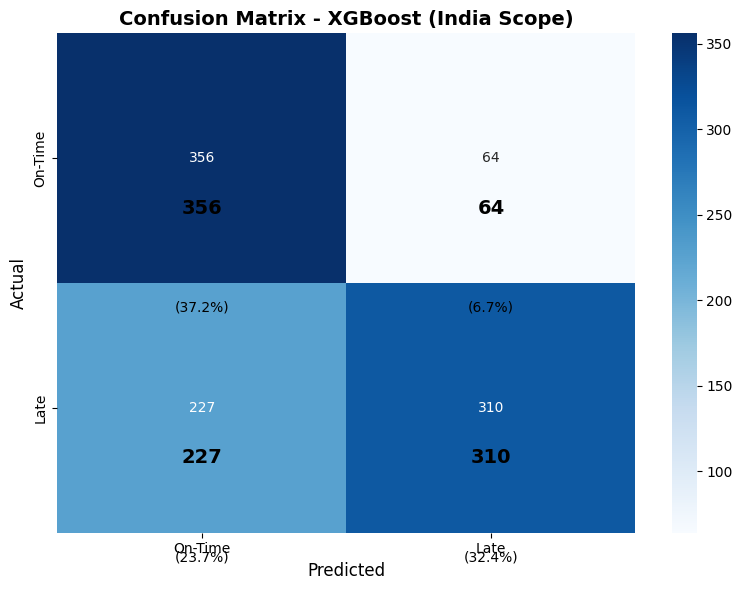

   ✓ Saved: confusion_matrix_heatmap.png

   Confusion Matrix:
                 Predicted
                 On-Time  Late
   Actual On-Time   356     64
   Actual Late      227     310


In [70]:
# ==========================================
# CONFUSION MATRIX HEATMAP
# ==========================================

print("\n" + "="*80)
print("GENERATING CONFUSION MATRIX HEATMAP")
print("="*80)

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions from best model (XGBoost)
y_pred_xgb = pipe_xgb.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-Time', 'Late'],
            yticklabels=['On-Time', 'Late'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost (India Scope)', fontsize=14, fontweight='bold')

# Add annotations with percentages
total = np.sum(cm)
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.7, f'{cm[i,j]}', ha='center', va='center', fontsize=14, fontweight='bold')
        plt.text(j+0.5, i+1.1, f'({cm[i,j]/total*100:.1f}%)', ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
# plt.close()

print("   ✓ Saved: confusion_matrix_heatmap.png")
print("\n   Confusion Matrix:")
print(f"                 Predicted")
print(f"                 On-Time  Late")
print(f"   Actual On-Time   {cm[0][0]}     {cm[0][1]}")
print(f"   Actual Late      {cm[1][0]}     {cm[1][1]}")


GENERATING FEATURE IMPORTANCE COMPARISON CHART


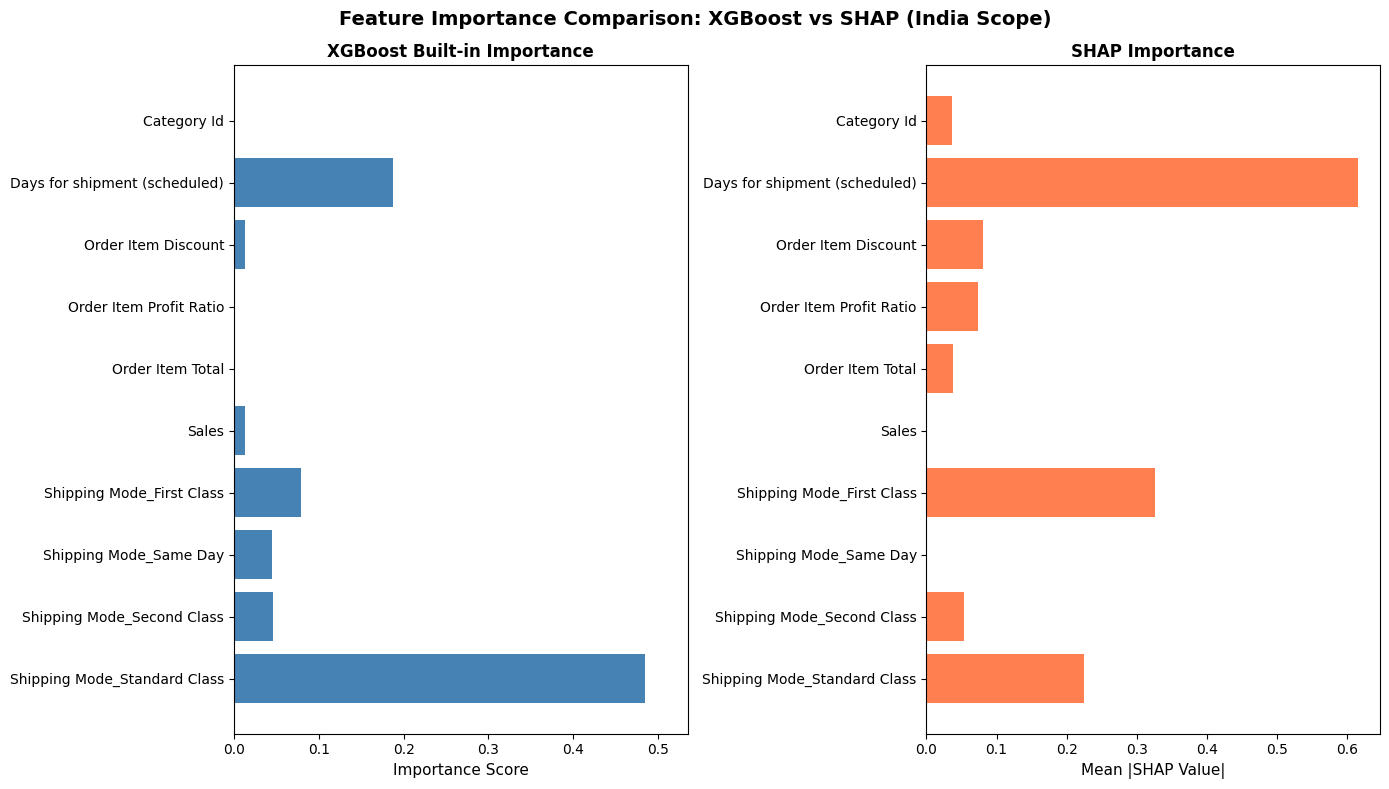

   ✓ Saved: feature_importance_comparison.png

   Top 5 Features Comparison:
   Feature                                     XGBoost            SHAP
   -----------------------------------------------------------------
   Category Id                                  0.0000          0.0358
   Days for shipment (scheduled)                0.1871          0.6160
   Order Item Discount                          0.0129          0.0803
   Order Item Profit Ratio                      0.0000          0.0734
   Order Item Total                             0.0000          0.0381


In [71]:
# ==========================================
# FEATURE IMPORTANCE COMPARISON (XGBoost vs SHAP)
# ==========================================

print("\n" + "="*80)
print("GENERATING FEATURE IMPORTANCE COMPARISON CHART")
print("="*80)

# Get XGBoost built-in feature importance
xgb_importance = pipe_xgb.named_steps['clf'].feature_importances_

# Get feature names after preprocessing
cat_features = pipe_xgb.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names_all = numeric_cols + list(cat_features)

# Create DataFrame for built-in importance
builtin_df = pd.DataFrame({
    'feature': feature_names_all,
    'importance_xgb': xgb_importance
}).sort_values('importance_xgb', ascending=False).head(10)

# Get SHAP importance (from your saved file)
shap_df = pd.read_csv('shap_feature_importance.csv')
shap_df.columns = ['feature', 'importance_shap']
shap_top10 = shap_df.head(10)

# Merge for comparison
comparison_df = builtin_df.merge(shap_top10, on='feature', how='outer').fillna(0)

# Plot side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Plot 1: XGBoost Built-in Importance
axes[0].barh(comparison_df['feature'][:10][::-1], comparison_df['importance_xgb'][:10][::-1], color='steelblue')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('XGBoost Built-in Importance', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, comparison_df['importance_xgb'].max() + 0.05)

# Plot 2: SHAP Importance
axes[1].barh(comparison_df['feature'][:10][::-1], comparison_df['importance_shap'][:10][::-1], color='coral')
axes[1].set_xlabel('Mean |SHAP Value|', fontsize=11)
axes[1].set_title('SHAP Importance', fontsize=12, fontweight='bold')

plt.suptitle('Feature Importance Comparison: XGBoost vs SHAP (India Scope)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
# plt.close()

print("   ✓ Saved: feature_importance_comparison.png")
print("\n   Top 5 Features Comparison:")
print("   {:<35} {:>15} {:>15}".format("Feature", "XGBoost", "SHAP"))
print("   " + "-" * 65)
for _, row in comparison_df.head(5).iterrows():
    print("   {:<35} {:>15.4f} {:>15.4f}".format(row['feature'][:35], row['importance_xgb'], row['importance_shap']))